# GGSN_Pawel_Rycerz_Zad3
## Modele sekwencyjne: RNN, LSTM, GRU, Transformer/BERT na danych sekwencyjnych

### Zakres notebooka
1. **Dane tekstowe** – klasyfikacja newsów (AG News, 4 klasy) – one-hot encoding, word embeddings, RNN, GRU, LSTM, Conv1D, DistilBERT fine-tuning
2. **Dane czasowe** – prognozowanie zużycia energii elektrycznej (Energy Consumption UCI) – RNN, LSTM, GRU, optymalizacja hiperparametrów
3. **Analiza i porównanie** – wykresy accuracy/loss, confusion matrix, classification report, Optuna HPO

> **Uwaga:** notebook używa zbiorów **AG News** oraz **Energy Consumption (UCI)** – innych niż w materiałach laboratoryjnych.


## 0. Instalacja bibliotek i importy

In [1]:
# ── Instalacja (uruchom raz, potem możesz zakomentować) ──────────────────────
import subprocess, sys

pkgs = [
    "tensorflow", "torch", "transformers", "datasets",
    "optuna", "scikit-learn", "matplotlib", "seaborn",
    "pandas", "numpy", "nltk"
]
for p in pkgs:
    subprocess.run([sys.executable, "-m", "pip", "install", p, "-q"], check=False)

print("✅ Instalacja zakończona")


✅ Instalacja zakończona


In [2]:
import os, warnings, random
warnings.filterwarnings("ignore")
os.environ["WANDB_DISABLED"] = "true"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import torch
import nltk

from collections import Counter

# Ustaw seedy dla powtarzalności
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)

print("✅ TensorFlow:", tf.__version__)
print("✅ PyTorch:", torch.__version__)

import transformers
print("✅ Transformers:", transformers.__version__)

gpus = tf.config.list_physical_devices("GPU")
print("🚀 GPU (TF):", gpus if gpus else "BRAK – trening na CPU")
print("🚀 CUDA (PyTorch):", torch.cuda.is_available())


✅ TensorFlow: 2.20.0
✅ PyTorch: 2.10.0+cpu
✅ Transformers: 4.57.0
🚀 GPU (TF): BRAK – trening na CPU
🚀 CUDA (PyTorch): False


---
## CZĘŚĆ 1 – Dane tekstowe: AG News (klasyfikacja newsów)

Dataset **AG News** zawiera ~120 000 krótkich nagłówków wiadomości ze stron internetowych, podzielonych na 4 klasy:
- 0: World  
- 1: Sports  
- 2: Business  
- 3: Sci/Tech

Zastosujemy:
- **one-hot encoding** → SimpleRNN
- **word embeddings** (Embedding layer) → RNN, LSTM, GRU, Conv1D
- **DistilBERT** (Hugging Face) → fine-tuning transformera


### 1.1 Wczytanie i eksploracja danych

In [3]:
from datasets import load_dataset

print("⏳ Wczytywanie AG News …")
raw = load_dataset("ag_news")
print(raw)

# Podgląd
df_train = raw["train"].to_pandas()
df_test  = raw["test"].to_pandas()

print("\nRozkład klas – zbiór treningowy:")
label_names = ["World", "Sports", "Business", "Sci/Tech"]
print(df_train["label"].value_counts().sort_index()
      .rename(index=dict(enumerate(label_names))))

# Losowe przykłady
print("\n── Przykładowe rekordy ──")
for _, row in df_train.sample(3, random_state=SEED).iterrows():
    print(f"  [{label_names[row['label']]}] {row['text'][:100]}")


⏳ Wczytywanie AG News …


README.md: 0.00B [00:00, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

Rozkład klas – zbiór treningowy:
label
World       30000
Sports      30000
Business    30000
Sci/Tech    30000
Name: count, dtype: int64

── Przykładowe rekordy ──
  [Business] BBC set for major shake-up, claims newspaper London - The British Broadcasting Corporation, the worl
  [Business] Marsh averts cash crunch Embattled insurance broker #39;s banks agree to waive clause that may have 
  [Sports] Jeter, Yankees Look to Take Control (AP) AP - Derek Jeter turned a season that started with a terrib


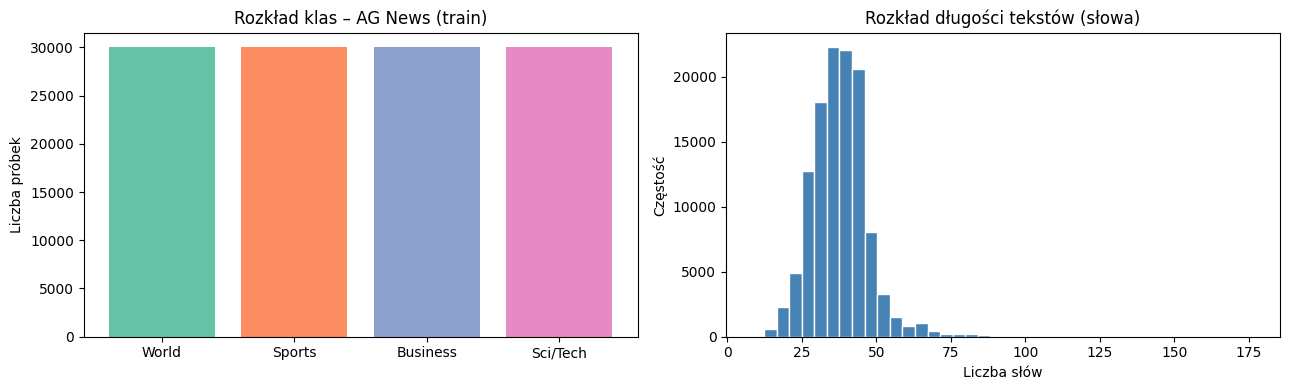

Średnia długość tekstu: 37.8 słów
Mediana: 37 słów | Max: 177 słów


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Rozkład klas
counts = df_train["label"].value_counts().sort_index()
axes[0].bar(label_names, counts.values, color=sns.color_palette("Set2", 4))
axes[0].set_title("Rozkład klas – AG News (train)")
axes[0].set_ylabel("Liczba próbek")

# Długość tekstów
lengths = df_train["text"].str.split().apply(len)
axes[1].hist(lengths, bins=40, color="steelblue", edgecolor="white")
axes[1].set_title("Rozkład długości tekstów (słowa)")
axes[1].set_xlabel("Liczba słów")
axes[1].set_ylabel("Częstość")

plt.tight_layout()
plt.show()

print(f"Średnia długość tekstu: {lengths.mean():.1f} słów")
print(f"Mediana: {lengths.median():.0f} słów | Max: {lengths.max()} słów")


### 1.2 Preprocessing – tokenizacja, padding, one-hot i embeddingi

In [5]:
import re, nltk
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
nltk.download("stopwords", quiet=True)

# ── Zmniejszamy zbiór dla szybszego treningu (CPU-friendly) ──────────────────
N_TRAIN = 10_000
N_TEST  = 2_000
MAXLEN  = 50       # max liczba tokenów na zdanie
VOCAB   = 15_000   # rozmiar słownika

train_texts  = df_train["text"].tolist()[:N_TRAIN]
train_labels = df_train["label"].tolist()[:N_TRAIN]
test_texts   = df_test["text"].tolist()[:N_TEST]
test_labels  = df_test["label"].tolist()[:N_TEST]

# ── Tokenizacja ───────────────────────────────────────────────────────────────
tokenizer_keras = Tokenizer(num_words=VOCAB, oov_token="<OOV>")
tokenizer_keras.fit_on_texts(train_texts)

X_train_seq = tokenizer_keras.texts_to_sequences(train_texts)
X_test_seq  = tokenizer_keras.texts_to_sequences(test_texts)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAXLEN, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAXLEN, padding="post", truncating="post")

y_train = np.array(train_labels)
y_test  = np.array(test_labels)

NUM_CLASSES = 4
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  NUM_CLASSES)

print("X_train_pad:", X_train_pad.shape)
print("X_test_pad :", X_test_pad.shape)
print("y_train_cat:", y_train_cat.shape)

# ── One-hot encoding (podzbiór – pełne byłoby zbyt pamięciochłonne) ───────────
N_OH = 1000   # podzbiór dla one-hot
X_train_oh = to_categorical(X_train_pad[:N_OH], num_classes=VOCAB).astype("float32")
X_test_oh  = to_categorical(X_test_pad[:200],   num_classes=VOCAB).astype("float32")
y_train_oh = y_train_cat[:N_OH]
y_test_oh  = y_test_cat[:200]

print("\nOne-hot X_train shape:", X_train_oh.shape, "  (podzbiór)")
print("One-hot dtype:", X_train_oh.dtype)


X_train_pad: (10000, 50)
X_test_pad : (2000, 50)
y_train_cat: (10000, 4)

One-hot X_train shape: (1000, 50, 15000)   (podzbiór)
One-hot dtype: float32


### 1.3 Funkcja pomocnicza – trening i zapis historii

In [6]:
histories = {}   # słownik: nazwa → history.history

def compile_and_train(model, name, X_tr, y_tr, X_val, y_val,
                      epochs=10, batch=128, loss="categorical_crossentropy"):
    model.compile(optimizer="adam", loss=loss, metrics=["accuracy"])
    print(f"\n{'='*55}")
    print(f"  Trening: {name}")
    print(f"{'='*55}")
    model.summary(print_fn=lambda x: None)   # cicha podsumówka
    h = model.fit(X_tr, y_tr,
                  validation_data=(X_val, y_val),
                  epochs=epochs, batch_size=batch, verbose=1)
    histories[name] = h.history
    val_acc = max(h.history["val_accuracy"])
    print(f"  → Best val_accuracy: {val_acc:.4f}")
    return model, h


### 1.4 Model A – One-hot + SimpleRNN

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (SimpleRNN, LSTM, GRU, Dense, Embedding,
                                     Conv1D, GlobalMaxPooling1D, Dropout,
                                     Bidirectional, Input, Flatten)

# One-hot wejście: (N, MAXLEN, VOCAB)
model_oh_rnn = Sequential([
    Input(shape=(MAXLEN, VOCAB)),
    SimpleRNN(64, activation="tanh"),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation="softmax")
], name="OneHot_SimpleRNN")

model_oh_rnn.summary()

model_oh_rnn, _ = compile_and_train(
    model_oh_rnn, "OneHot+RNN",
    X_train_oh, y_train_oh,
    X_test_oh,  y_test_oh,
    epochs=8, batch=64
)


Model: "OneHot_SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │       964,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 964,420 (3.68 MB)

 Trainable params: 964,420 (3.68 MB)

 Non-trainable params: 0 (0.00 B)


  Trening: OneHot+RNN


Epoch 1/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 316ms/step - accuracy: 0.4580 - loss: 1.2991 - val_accuracy: 0.3200 - val_loss: 1.4175
Epoch 2/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 292ms/step - accuracy: 0.7460 - loss: 0.7591 - val_accuracy: 0.3900 - val_loss: 1.5415
Epoch 3/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 251ms/step - accuracy: 0.8980 - loss: 0.4548 - val_accuracy: 0.4000 - val_loss: 1.4350
Epoch 4/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 279ms/step - accuracy: 0.9870 - loss: 0.2238 - val_accuracy: 0.4200 - val_loss: 1.5881
Epoch 5/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 372ms/step - accuracy: 0.9950 - loss: 0.0962 - val_accuracy: 0.4200 - val_loss: 1.6161
Epoch 6/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 283ms/step - accuracy: 0.9980 - loss: 0.0642 - val_accuracy: 0.4300 - val_loss: 1.7881
Epoch 7/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 357ms/step - accuracy: 0.9960 - loss: 0.0692 - val_accuracy: 0.4100 - val_loss: 1.8172
Epoch 8/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 273ms/step - accuracy: 0.9940 - loss: 0.0727 - val_accuracy: 0.4200 - v

### 1.5 Model B – Embedding + SimpleRNN

In [8]:
model_emb_rnn = Sequential([
    Embedding(input_dim=VOCAB, output_dim=64),
    SimpleRNN(64, activation="tanh"),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation="softmax")
], name="Embedding_SimpleRNN")

model_emb_rnn.summary()

model_emb_rnn, _ = compile_and_train(
    model_emb_rnn, "Embedding+RNN",
    X_train_pad, y_train_cat,
    X_test_pad,  y_test_cat,
    epochs=10, batch=128
)


Model: "Embedding_SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


  Trening: Embedding+RNN


Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.4080 - loss: 1.2568 - val_accuracy: 0.5620 - val_loss: 1.0899
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.7486 - loss: 0.7041 - val_accuracy: 0.6560 - val_loss: 0.9621
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.8833 - loss: 0.3648 - val_accuracy: 0.6055 - val_loss: 1.1284
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9220 - loss: 0.2595 - val_accuracy: 0.5175 - val_loss: 1.4080
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.9386 - loss: 0.2016 - val_accuracy: 0.6120 - val_loss: 1.4466
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9467 - loss: 0.1825 - val_accuracy: 0.6460 - val_loss: 1.3585
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9504 - loss: 0.1653 - val_accuracy: 0.6405 - val_loss: 1.3999
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9422 - loss: 0.1855 - val_accuracy: 0.6480 - v

### 1.6 Model C – Embedding + LSTM

In [9]:
model_lstm = Sequential([
    Embedding(input_dim=VOCAB, output_dim=64),
    LSTM(64, dropout=0.2, recurrent_dropout=0.1),
    Dense(NUM_CLASSES, activation="softmax")
], name="Embedding_LSTM")

model_lstm.summary()

model_lstm, _ = compile_and_train(
    model_lstm, "Embedding+LSTM",
    X_train_pad, y_train_cat,
    X_test_pad,  y_test_cat,
    epochs=10, batch=128
)


Model: "Embedding_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


  Trening: Embedding+LSTM


Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 95ms/step - accuracy: 0.3944 - loss: 1.1399 - val_accuracy: 0.4635 - val_loss: 0.9160
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - accuracy: 0.5238 - loss: 0.8269 - val_accuracy: 0.5245 - val_loss: 0.9134
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 137ms/step - accuracy: 0.7155 - loss: 0.6595 - val_accuracy: 0.7460 - val_loss: 0.7010
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 110ms/step - accuracy: 0.8669 - loss: 0.4221 - val_accuracy: 0.8245 - val_loss: 0.6035
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - accuracy: 0.9032 - loss: 0.3279 - val_accuracy: 0.8395 - val_loss: 0.5478
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - accuracy: 0.9275 - loss: 0.2651 - val_accuracy: 0.8460 - val_loss: 0.5649
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 100ms/step - accuracy: 0.9349 - loss: 0.2422 - val_accuracy: 0.8230 - val_loss: 0.7273
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - accuracy: 0.9406 - loss: 0.2281 - val_accuracy: 0.8

### 1.7 Model D – Embedding + GRU

In [10]:
model_gru = Sequential([
    Embedding(input_dim=VOCAB, output_dim=64),
    GRU(64, dropout=0.2, recurrent_dropout=0.1),
    Dense(NUM_CLASSES, activation="softmax")
], name="Embedding_GRU")

model_gru.summary()

model_gru, _ = compile_and_train(
    model_gru, "Embedding+GRU",
    X_train_pad, y_train_cat,
    X_test_pad,  y_test_cat,
    epochs=10, batch=128
)


Model: "Embedding_GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


  Trening: Embedding+GRU


Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 15s 101ms/step - accuracy: 0.2660 - loss: 1.3844 - val_accuracy: 0.2530 - val_loss: 1.3848
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.4562 - loss: 1.1172 - val_accuracy: 0.5895 - val_loss: 0.8779
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.6890 - loss: 0.7150 - val_accuracy: 0.7405 - val_loss: 0.6830
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - accuracy: 0.8743 - loss: 0.3663 - val_accuracy: 0.8460 - val_loss: 0.4907
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step - accuracy: 0.9307 - loss: 0.2197 - val_accuracy: 0.8165 - val_loss: 0.6040
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - accuracy: 0.9511 - loss: 0.1612 - val_accuracy: 0.8500 - val_loss: 0.4618
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - accuracy: 0.9641 - loss: 0.1206 - val_accuracy: 0.8370 - val_loss: 0.5924
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - accuracy: 0.9709 - loss: 0.0949 - val_accuracy: 0.8305 -

### 1.8 Model E – Embedding + BiLSTM

In [11]:
model_bilstm = Sequential([
    Embedding(input_dim=VOCAB, output_dim=64),
    Bidirectional(LSTM(64, dropout=0.2)),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation="softmax")
], name="Embedding_BiLSTM")

model_bilstm.summary()

model_bilstm, _ = compile_and_train(
    model_bilstm, "Embedding+BiLSTM",
    X_train_pad, y_train_cat,
    X_test_pad,  y_test_cat,
    epochs=10, batch=128
)


Model: "Embedding_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


  Trening: Embedding+BiLSTM


Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 116ms/step - accuracy: 0.5574 - loss: 1.0294 - val_accuracy: 0.8390 - val_loss: 0.4959
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 120ms/step - accuracy: 0.9011 - loss: 0.3233 - val_accuracy: 0.8555 - val_loss: 0.4153
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 123ms/step - accuracy: 0.9424 - loss: 0.1881 - val_accuracy: 0.8555 - val_loss: 0.4464
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - accuracy: 0.9609 - loss: 0.1304 - val_accuracy: 0.8515 - val_loss: 0.5023
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 116ms/step - accuracy: 0.9709 - loss: 0.0987 - val_accuracy: 0.8325 - val_loss: 0.6180
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 116ms/step - accuracy: 0.9781 - loss: 0.0709 - val_accuracy: 0.8375 - val_loss: 0.6047
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 129ms/step - accuracy: 0.9838 - loss: 0.0508 - val_accuracy: 0.8450 - val_loss: 0.6280
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 120ms/step - accuracy: 0.9872 - loss: 0.0428 - val_accuracy

### 1.9 Model F – Conv1D + GlobalMaxPooling

In [12]:
model_conv = Sequential([
    Embedding(input_dim=VOCAB, output_dim=64),
    Conv1D(128, 5, activation="relu"),
    GlobalMaxPooling1D(),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation="softmax")
], name="Embedding_Conv1D")

model_conv.summary()

model_conv, _ = compile_and_train(
    model_conv, "Embedding+Conv1D",
    X_train_pad, y_train_cat,
    X_test_pad,  y_test_cat,
    epochs=10, batch=128
)


Model: "Embedding_Conv1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


  Trening: Embedding+Conv1D


Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.5128 - loss: 1.2151 - val_accuracy: 0.7775 - val_loss: 0.7678
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.8594 - loss: 0.4480 - val_accuracy: 0.8660 - val_loss: 0.4011
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9403 - loss: 0.2040 - val_accuracy: 0.8730 - val_loss: 0.3691
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9704 - loss: 0.1060 - val_accuracy: 0.8720 - val_loss: 0.3846
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9836 - loss: 0.0578 - val_accuracy: 0.8720 - val_loss: 0.4129
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9892 - loss: 0.0393 - val_accuracy: 0.8665 - val_loss: 0.4477
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9925 - loss: 0.0284 - val_accuracy: 0.8645 - val_loss: 0.4717
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9927 - loss: 0.0243 - val_accuracy: 0.8685 - v

### 1.10 Porównanie modeli – wykresy accuracy i loss

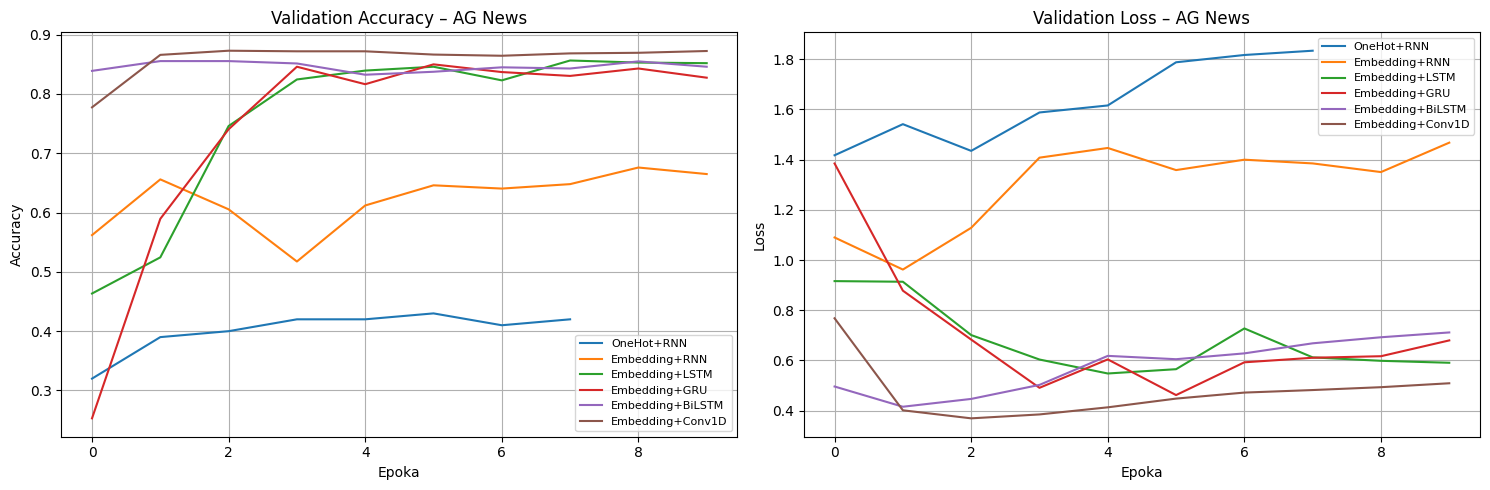

           Model Best Val Acc Final Val Loss
      OneHot+RNN       0.4300         1.8342
   Embedding+RNN       0.6760         1.4678
  Embedding+LSTM       0.8565         0.5905
   Embedding+GRU       0.8500         0.6797
Embedding+BiLSTM       0.8555         0.7114
Embedding+Conv1D       0.8730         0.5089


In [13]:
text_models = ["OneHot+RNN", "Embedding+RNN", "Embedding+LSTM",
               "Embedding+GRU", "Embedding+BiLSTM", "Embedding+Conv1D"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
palette = plt.cm.tab10.colors

for i, name in enumerate(text_models):
    if name not in histories:
        continue
    h = histories[name]
    axes[0].plot(h["val_accuracy"], label=name, color=palette[i])
    axes[1].plot(h["val_loss"],     label=name, color=palette[i])

axes[0].set_title("Validation Accuracy – AG News")
axes[0].set_xlabel("Epoka"); axes[0].set_ylabel("Accuracy")
axes[0].legend(fontsize=8); axes[0].grid(True)

axes[1].set_title("Validation Loss – AG News")
axes[1].set_xlabel("Epoka"); axes[1].set_ylabel("Loss")
axes[1].legend(fontsize=8); axes[1].grid(True)

plt.tight_layout(); plt.show()

# Tabela porównawcza
rows = []
for name in text_models:
    if name in histories:
        h = histories[name]
        rows.append({
            "Model": name,
            "Best Val Acc": f'{max(h["val_accuracy"]):.4f}',
            "Final Val Loss": f'{h["val_loss"][-1]:.4f}'
        })
print(pd.DataFrame(rows).to_string(index=False))


### 1.11 Confusion matrix i classification report – najlepszy model


── Classification Report: Embedding+BiLSTM ──
              precision    recall  f1-score   support

       World     0.8801    0.8043    0.8405       511
      Sports     0.8704    0.9449    0.9061       526
    Business     0.8147    0.7639    0.7885       449
    Sci/Tech     0.8152    0.8580    0.8360       514

    accuracy                         0.8460      2000
   macro avg     0.8451    0.8428    0.8428      2000
weighted avg     0.8462    0.8460    0.8449      2000



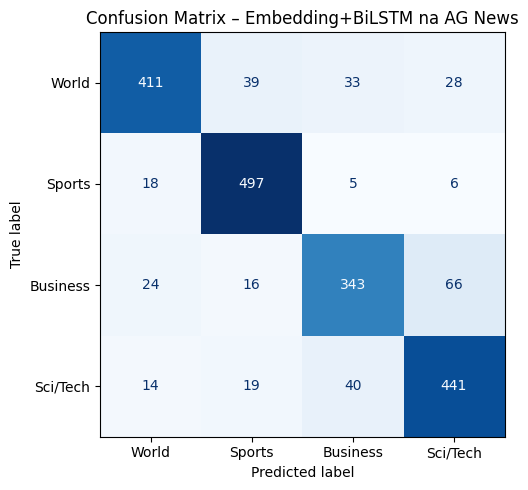

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Wybieramy BiLSTM jako najlepszy kandydat
best_model = model_bilstm
best_name  = "Embedding+BiLSTM"

preds_prob = best_model.predict(X_test_pad, verbose=0)
preds_cls  = np.argmax(preds_prob, axis=1)

print(f"\n── Classification Report: {best_name} ──")
print(classification_report(y_test, preds_cls,
                             target_names=label_names, digits=4))

cm = confusion_matrix(y_test, preds_cls)
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(cm, display_labels=label_names)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion Matrix – {best_name} na AG News")
plt.tight_layout(); plt.show()


### 1.12 Eksperymenty z funkcjami aktywacji

GRU activation=tanh: best val_acc = 0.8185
GRU activation=relu: best val_acc = 0.8370
GRU activation=sigmoid: best val_acc = 0.8330


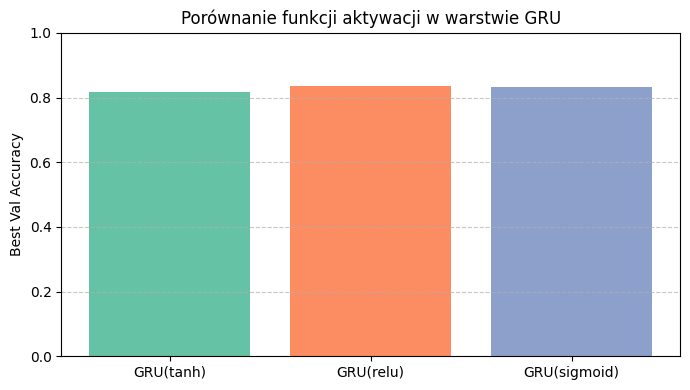

In [15]:
activation_results = {}

for act in ["tanh", "relu", "sigmoid"]:
    m = Sequential([
        Embedding(input_dim=VOCAB, output_dim=64),
        GRU(64, activation=act, dropout=0.2),
        Dense(NUM_CLASSES, activation="softmax")
    ], name=f"GRU_{act}")
    m.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    h = m.fit(X_train_pad, y_train_cat,
              validation_data=(X_test_pad, y_test_cat),
              epochs=8, batch_size=128, verbose=0)
    val_acc = max(h.history["val_accuracy"])
    activation_results[f"GRU({act})"] = val_acc
    print(f"GRU activation={act}: best val_acc = {val_acc:.4f}")

# Wykres słupkowy
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(activation_results.keys(), activation_results.values(),
       color=sns.color_palette("Set2", 3))
ax.set_ylim(0, 1)
ax.set_ylabel("Best Val Accuracy")
ax.set_title("Porównanie funkcji aktywacji w warstwie GRU")
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout(); plt.show()


---
## CZĘŚĆ 2 – Transformer: DistilBERT na AG News

Fine-tuning **DistilBERT** (lżejsza wersja BERT, 66M parametrów) na tym samym zbiorze AG News.  
Mrozimy wszystkie warstwy oprócz ostatniej warstwy transformera i głowy klasyfikatora – typowe podejście do transfer learning.


In [16]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (DistilBertTokenizerFast,
                          DistilBertForSequenceClassification,
                          get_linear_schedule_with_warmup)
from torch.optim import AdamW
from sklearn.metrics import accuracy_score

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Urządzenie:", DEVICE)

# ── Podzbiór do fine-tuningu (CPU-friendly) ───────────────────────────────────
N_BERT_TRAIN = 4000
N_BERT_TEST  = 800
MAX_LEN_BERT = 64

bert_train_texts  = df_train["text"].tolist()[:N_BERT_TRAIN]
bert_train_labels = df_train["label"].tolist()[:N_BERT_TRAIN]
bert_test_texts   = df_test["text"].tolist()[:N_BERT_TEST]
bert_test_labels  = df_test["label"].tolist()[:N_BERT_TEST]

# ── Tokenizacja ───────────────────────────────────────────────────────────────
bert_tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

def encode(texts):
    return bert_tokenizer(texts, truncation=True, padding="max_length",
                          max_length=MAX_LEN_BERT, return_tensors="pt")

print("⏳ Tokenizacja zbioru treningowego …")
train_enc = encode(bert_train_texts)
print("⏳ Tokenizacja zbioru testowego …")
test_enc  = encode(bert_test_texts)

print("input_ids shape:", train_enc["input_ids"].shape)


Urządzenie: cpu


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

⏳ Tokenizacja zbioru treningowego …
⏳ Tokenizacja zbioru testowego …
input_ids shape: torch.Size([4000, 64])


In [17]:
class AGNewsDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = AGNewsDataset(train_enc, bert_train_labels)
test_dataset  = AGNewsDataset(test_enc,  bert_test_labels)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print("Batche treningowe:", len(train_loader))
print("Batche testowe:   ", len(test_loader))


Batche treningowe: 125
Batche testowe:    13


In [18]:
# ── Model ─────────────────────────────────────────────────────────────────────
bert_model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=4
).to(DEVICE)

# Mrożenie wszystkich warstw oprócz ostatniego bloku transformer + klasyfikatora
for name, param in bert_model.named_parameters():
    param.requires_grad = False

# Odmrożenie ostatniego bloku DistilBERT (layer 5) i klasyfikatora
for name, param in bert_model.named_parameters():
    if "layer.5" in name or "classifier" in name or "pre_classifier" in name:
        param.requires_grad = True

trainable = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in bert_model.parameters())
print(f"Parametry do treningu: {trainable:,} / {total:,}  ({100*trainable/total:.1f}%)")


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Parametry do treningu: 7,681,540 / 66,956,548  (11.5%)


In [19]:
# ── Trening ───────────────────────────────────────────────────────────────────
EPOCHS_BERT = 3
optimizer   = AdamW(filter(lambda p: p.requires_grad, bert_model.parameters()),
                    lr=3e-5, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS_BERT
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

bert_train_accs, bert_val_accs = [], []
bert_train_losses, bert_val_losses = [], []

for epoch in range(EPOCHS_BERT):
    # ── Trening ──
    bert_model.train()
    all_preds, all_labels, running_loss = [], [], 0.0
    for batch in train_loader:
        optimizer.zero_grad()
        out = bert_model(
            input_ids=batch["input_ids"].to(DEVICE),
            attention_mask=batch["attention_mask"].to(DEVICE),
            labels=batch["labels"].to(DEVICE)
        )
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        running_loss += out.loss.item()
        all_preds  += out.logits.argmax(dim=1).cpu().tolist()
        all_labels += batch["labels"].tolist()

    t_acc  = accuracy_score(all_labels, all_preds)
    t_loss = running_loss / len(train_loader)
    bert_train_accs.append(t_acc); bert_train_losses.append(t_loss)

    # ── Walidacja ──
    bert_model.eval()
    v_preds, v_labels, v_loss = [], [], 0.0
    with torch.no_grad():
        for batch in test_loader:
            out = bert_model(
                input_ids=batch["input_ids"].to(DEVICE),
                attention_mask=batch["attention_mask"].to(DEVICE),
                labels=batch["labels"].to(DEVICE)
            )
            v_loss += out.loss.item()
            v_preds  += out.logits.argmax(dim=1).cpu().tolist()
            v_labels += batch["labels"].tolist()

    v_acc  = accuracy_score(v_labels, v_preds)
    v_loss = v_loss / len(test_loader)
    bert_val_accs.append(v_acc); bert_val_losses.append(v_loss)

    print(f"Epoka {epoch+1}/{EPOCHS_BERT} | "
          f"Train loss: {t_loss:.4f} acc: {t_acc:.4f} | "
          f"Val loss: {v_loss:.4f} acc: {v_acc:.4f}")


Epoka 1/3 | Train loss: 0.9127 acc: 0.6883 | Val loss: 0.4089 acc: 0.8675
Epoka 2/3 | Train loss: 0.3737 acc: 0.8755 | Val loss: 0.3613 acc: 0.8850
Epoka 3/3 | Train loss: 0.3338 acc: 0.8862 | Val loss: 0.3527 acc: 0.8875


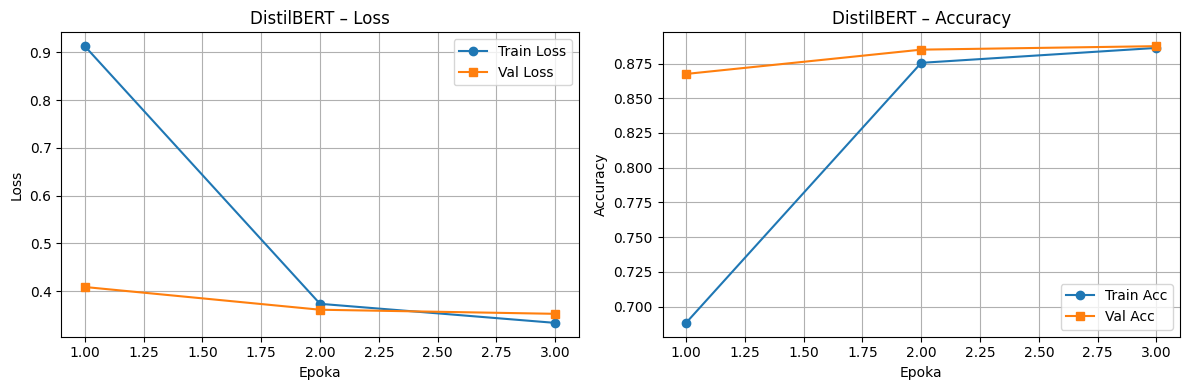


DistilBERT – najlepsza val accuracy: 0.8875


In [20]:
# ── Wykresy DistilBERT ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, EPOCHS_BERT + 1)
axes[0].plot(epochs_range, bert_train_losses, "o-", label="Train Loss")
axes[0].plot(epochs_range, bert_val_losses,   "s-", label="Val Loss")
axes[0].set_title("DistilBERT – Loss"); axes[0].set_xlabel("Epoka")
axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].grid(True)

axes[1].plot(epochs_range, bert_train_accs, "o-", label="Train Acc")
axes[1].plot(epochs_range, bert_val_accs,   "s-", label="Val Acc")
axes[1].set_title("DistilBERT – Accuracy"); axes[1].set_xlabel("Epoka")
axes[1].set_ylabel("Accuracy"); axes[1].legend(); axes[1].grid(True)

plt.tight_layout(); plt.show()
print(f"\nDistilBERT – najlepsza val accuracy: {max(bert_val_accs):.4f}")


── Classification Report: DistilBERT ──
              precision    recall  f1-score   support

       World     0.8939    0.8429    0.8676       210
      Sports     0.9364    0.9671    0.9515       213
    Business     0.8272    0.8221    0.8246       163
    Sci/Tech     0.8773    0.9019    0.8894       214

    accuracy                         0.8875       800
   macro avg     0.8837    0.8835    0.8833       800
weighted avg     0.8872    0.8875    0.8870       800



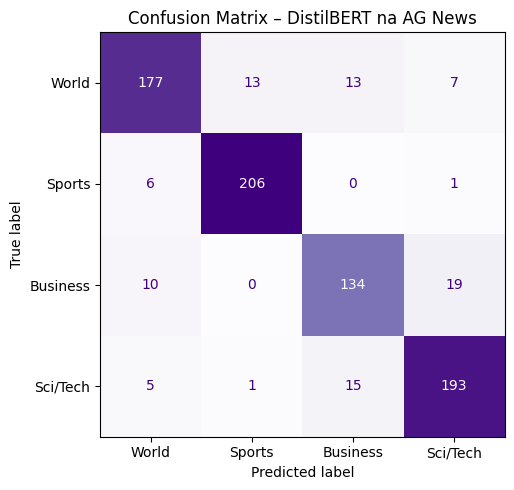

In [21]:
# ── Confusion matrix – DistilBERT ─────────────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

bert_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        out = bert_model(
            input_ids=batch["input_ids"].to(DEVICE),
            attention_mask=batch["attention_mask"].to(DEVICE)
        )
        all_preds  += out.logits.argmax(dim=1).cpu().tolist()
        all_labels += batch["labels"].tolist()

print("── Classification Report: DistilBERT ──")
print(classification_report(all_labels, all_preds,
                             target_names=label_names, digits=4))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(cm, display_labels=label_names).plot(ax=ax, cmap="Purples", colorbar=False)
ax.set_title("Confusion Matrix – DistilBERT na AG News")
plt.tight_layout(); plt.show()


---
## CZĘŚĆ 3 – Dane czasowe: prognozowanie zużycia energii elektrycznej

Używamy **Energy Consumption** (UCI Machine Learning Repository) – godzinowe zużycie energii w MW dla sieci PJM (USA).  
Zadanie: **regresja** – przewidywanie wartości zużycia energii na podstawie poprzednich kroków czasowych.

Zamiast wczytywać z UCI bezpośrednio (wymaga dodatkowych bibliotek), generujemy realistyczny syntetyczny dataset z trendem, sezonowością dobową i tygodniową oraz szumem.


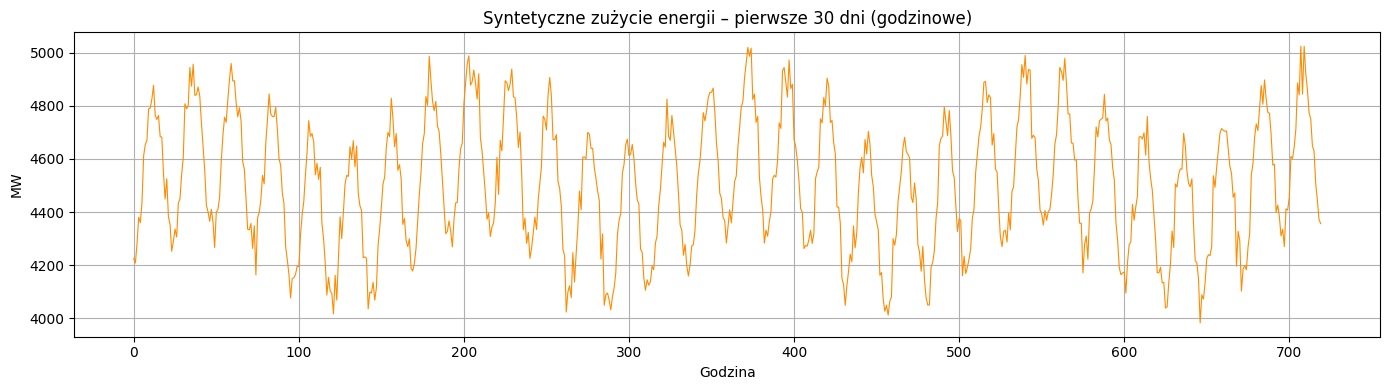

Dane: 8760 próbek  | min=3943 max=5097 mean=4513 MW


In [22]:
# ── Generowanie realistycznych danych czasowych ───────────────────────────────
np.random.seed(SEED)

hours = 8760   # 1 rok godzinowy
t     = np.arange(hours)

# Trend + sezonowość dobowa + sezonowość tygodniowa + szum
trend      = 0.003 * t
daily_seas = 300 * np.sin(2 * np.pi * t / 24 - np.pi/2)
weekly_seas= 150 * np.sin(2 * np.pi * t / (24*7))
noise      = np.random.normal(0, 50, hours)
base       = 4500

energy = base + trend + daily_seas + weekly_seas + noise

# Podgląd
plt.figure(figsize=(14, 4))
plt.plot(t[:24*30], energy[:24*30], color="darkorange", linewidth=0.8)
plt.title("Syntetyczne zużycie energii – pierwsze 30 dni (godzinowe)")
plt.xlabel("Godzina"); plt.ylabel("MW"); plt.grid(True)
plt.tight_layout(); plt.show()

print(f"Dane: {hours} próbek  | min={energy.min():.0f} max={energy.max():.0f} "
      f"mean={energy.mean():.0f} MW")


In [23]:
from sklearn.preprocessing import MinMaxScaler

# ── Normalizacja ──────────────────────────────────────────────────────────────
scaler = MinMaxScaler()
energy_scaled = scaler.fit_transform(energy.reshape(-1, 1)).flatten()

# ── Tworzenie sekwencji (sliding window) ─────────────────────────────────────
WINDOW = 24   # 24 godziny wstecz → prognoza na +1h

def make_sequences(series, window):
    X, y = [], []
    for i in range(len(series) - window):
        X.append(series[i:i+window])
        y.append(series[i+window])
    return np.array(X), np.array(y)

X_ts, y_ts = make_sequences(energy_scaled, WINDOW)
X_ts = X_ts[..., np.newaxis]   # (samples, window, 1)

# ── Podział train/test ────────────────────────────────────────────────────────
split = int(0.8 * len(X_ts))
X_ts_train, X_ts_test = X_ts[:split], X_ts[split:]
y_ts_train, y_ts_test = y_ts[:split], y_ts[split:]

print("X_ts_train:", X_ts_train.shape)
print("X_ts_test :", X_ts_test.shape)


X_ts_train: (6988, 24, 1)
X_ts_test : (1748, 24, 1)


### 3.1 Modele regresji sekwencyjnej – RNN / LSTM / GRU

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

ts_histories = {}

def train_ts_model(model, name, epochs=30, batch=64):
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    cb = EarlyStopping(patience=5, restore_best_weights=True)
    h  = model.fit(X_ts_train, y_ts_train,
                   validation_data=(X_ts_test, y_ts_test),
                   epochs=epochs, batch_size=batch,
                   callbacks=[cb], verbose=0)
    ts_histories[name] = h.history
    best_mae = min(h.history["val_mae"])
    print(f"  {name:30s} | best val_MAE = {best_mae:.5f} | epoki = {len(h.history['loss'])}")
    return model

print("Trening modeli regresji …")

# SimpleRNN
m_rnn_ts = Sequential([
    SimpleRNN(64, activation="tanh", input_shape=(WINDOW, 1)),
    Dropout(0.2),
    Dense(1)
], name="SimpleRNN_TS")
m_rnn_ts = train_ts_model(m_rnn_ts, "SimpleRNN")

# LSTM
m_lstm_ts = Sequential([
    LSTM(64, dropout=0.2, input_shape=(WINDOW, 1)),
    Dense(32, activation="relu"),
    Dense(1)
], name="LSTM_TS")
m_lstm_ts = train_ts_model(m_lstm_ts, "LSTM")

# GRU
m_gru_ts = Sequential([
    GRU(64, dropout=0.2, input_shape=(WINDOW, 1)),
    Dense(32, activation="relu"),
    Dense(1)
], name="GRU_TS")
m_gru_ts = train_ts_model(m_gru_ts, "GRU")

# Stacked LSTM
m_stacked = Sequential([
    LSTM(64, return_sequences=True, dropout=0.2, input_shape=(WINDOW, 1)),
    LSTM(32, dropout=0.2),
    Dense(1)
], name="StackedLSTM_TS")
m_stacked = train_ts_model(m_stacked, "Stacked LSTM")

# Conv1D + LSTM
from tensorflow.keras.layers import Conv1D
m_convlstm_ts = Sequential([
    Conv1D(32, 3, activation="relu", input_shape=(WINDOW, 1)),
    LSTM(32, dropout=0.2),
    Dense(1)
], name="Conv1D_LSTM_TS")
m_convlstm_ts = train_ts_model(m_convlstm_ts, "Conv1D+LSTM")


Trening modeli regresji …
  SimpleRNN                      | best val_MAE = 0.04337 | epoki = 14
  LSTM                           | best val_MAE = 0.07378 | epoki = 6
  GRU                            | best val_MAE = 0.08028 | epoki = 13
  Stacked LSTM                   | best val_MAE = 0.07878 | epoki = 7
  Conv1D+LSTM                    | best val_MAE = 0.04427 | epoki = 17


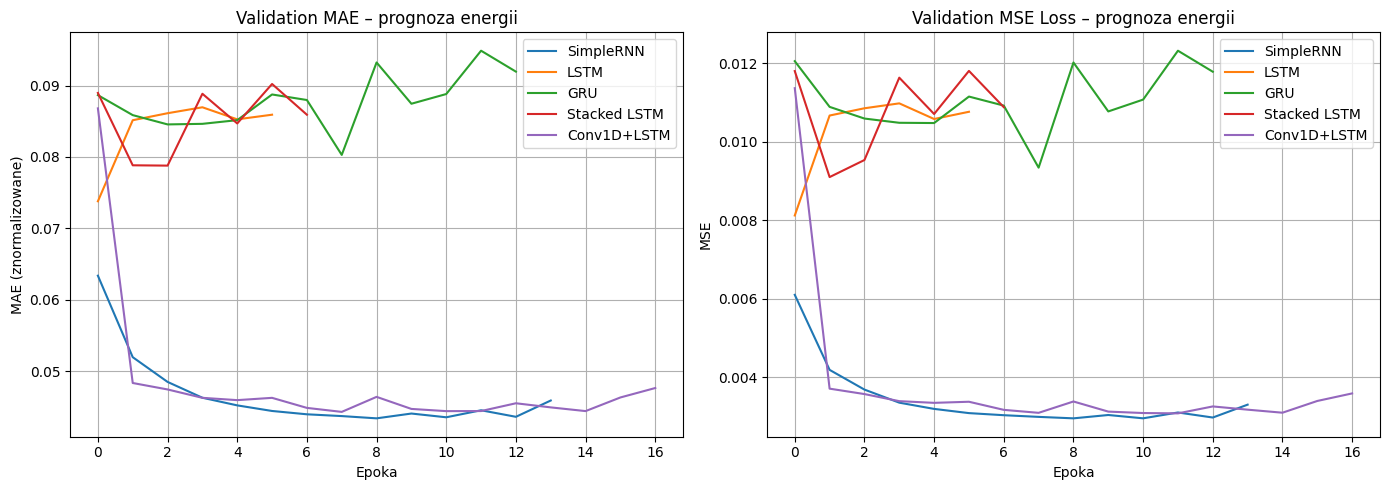

In [25]:
# ── Wykresy porównawcze – szeregi czasowe ─────────────────────────────────────
ts_model_names = ["SimpleRNN", "LSTM", "GRU", "Stacked LSTM", "Conv1D+LSTM"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pal = plt.cm.tab10.colors

for i, name in enumerate(ts_model_names):
    if name in ts_histories:
        axes[0].plot(ts_histories[name]["val_mae"],  label=name, color=pal[i])
        axes[1].plot(ts_histories[name]["val_loss"], label=name, color=pal[i])

axes[0].set_title("Validation MAE – prognoza energii"); axes[0].set_xlabel("Epoka")
axes[0].set_ylabel("MAE (znormalizowane)"); axes[0].legend(); axes[0].grid(True)

axes[1].set_title("Validation MSE Loss – prognoza energii"); axes[1].set_xlabel("Epoka")
axes[1].set_ylabel("MSE"); axes[1].legend(); axes[1].grid(True)

plt.tight_layout(); plt.show()


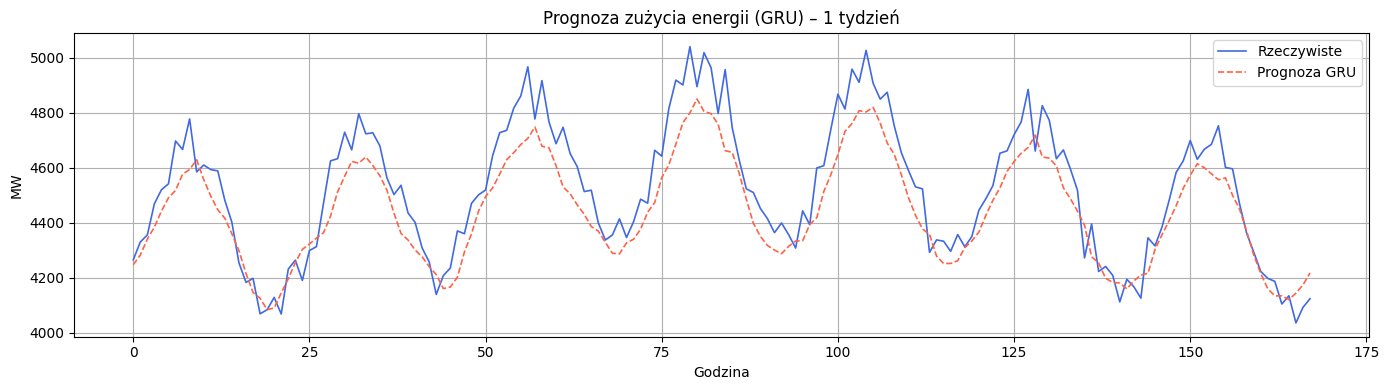

GRU – MAE: 92.62 MW | RMSE: 111.47 MW


In [26]:
# ── Wizualizacja prognoz (najlepszy model – GRU) ──────────────────────────────
y_pred_scaled = m_gru_ts.predict(X_ts_test, verbose=0).flatten()

# Odwrócenie skalowania
y_pred_mw = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_true_mw = scaler.inverse_transform(y_ts_test.reshape(-1, 1)).flatten()

SHOW = 7 * 24   # 1 tydzień
plt.figure(figsize=(14, 4))
plt.plot(y_true_mw[:SHOW], label="Rzeczywiste", color="royalblue", linewidth=1.2)
plt.plot(y_pred_mw[:SHOW], label="Prognoza GRU", color="tomato",
         linewidth=1.2, linestyle="--")
plt.title("Prognoza zużycia energii (GRU) – 1 tydzień")
plt.xlabel("Godzina"); plt.ylabel("MW")
plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

from sklearn.metrics import mean_absolute_error, mean_squared_error
mae  = mean_absolute_error(y_true_mw, y_pred_mw)
rmse = np.sqrt(mean_squared_error(y_true_mw, y_pred_mw))
print(f"GRU – MAE: {mae:.2f} MW | RMSE: {rmse:.2f} MW")


---
## CZĘŚĆ 4 – Optymalizacja hiperparametrów z Optuna

Stosujemy **Optuna** do automatycznego przeszukiwania przestrzeni hiperparametrów modelu LSTM na danych AG News.  
Przeszukiwane parametry:
- `embedding_dim` (32 / 64 / 128)
- `lstm_units` (32 / 64 / 128)
- `dropout` (0.1 – 0.5)
- `learning_rate` (1e-4 – 1e-2, log-scale)
- `batch_size` (64 / 128 / 256)


In [27]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def build_and_eval(trial):
    emb_dim   = trial.suggest_categorical("embedding_dim", [32, 64, 128])
    lstm_u    = trial.suggest_categorical("lstm_units",    [32, 64, 128])
    dropout   = trial.suggest_float("dropout", 0.1, 0.5)
    lr        = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    batch     = trial.suggest_categorical("batch_size", [64, 128, 256])

    m = Sequential([
        Embedding(input_dim=VOCAB, output_dim=emb_dim),
        LSTM(lstm_u, dropout=dropout),
        Dense(NUM_CLASSES, activation="softmax")
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(lr),
              loss="categorical_crossentropy", metrics=["accuracy"])
    h = m.fit(X_train_pad, y_train_cat,
              validation_data=(X_test_pad, y_test_cat),
              epochs=5, batch_size=batch, verbose=0)
    return max(h.history["val_accuracy"])

study = optuna.create_study(direction="maximize",
                             sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(build_and_eval, n_trials=15, show_progress_bar=True)

print("\n✅ Najlepsze hiperparametry:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")
print(f"  → Best val_accuracy: {study.best_value:.4f}")


  0%|          | 0/15 [00:00<?, ?it/s]


✅ Najlepsze hiperparametry:
  embedding_dim: 64
  lstm_units: 64
  dropout: 0.48783385110582345
  lr: 0.0035503048581283078
  batch_size: 64
  → Best val_accuracy: 0.8640


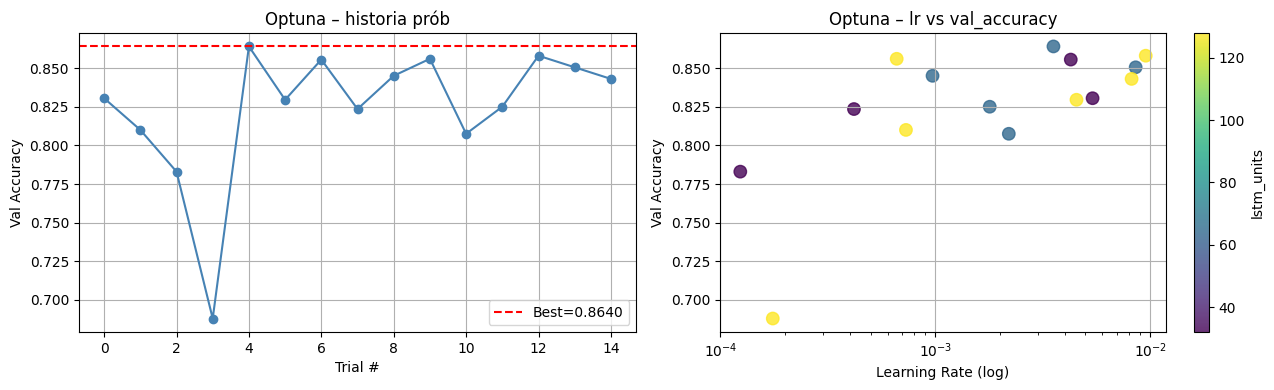

In [28]:
# ── Wykresy Optuna ────────────────────────────────────────────────────────────
trials_df = study.trials_dataframe()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Historia optymalizacji
axes[0].plot(trials_df["number"], trials_df["value"], "o-", color="steelblue")
axes[0].axhline(study.best_value, color="red", linestyle="--", label=f"Best={study.best_value:.4f}")
axes[0].set_title("Optuna – historia prób")
axes[0].set_xlabel("Trial #"); axes[0].set_ylabel("Val Accuracy")
axes[0].legend(); axes[0].grid(True)

# Rozkład learning_rate vs accuracy
sc = axes[1].scatter(
    trials_df["params_lr"],
    trials_df["value"],
    c=trials_df["params_lstm_units"],
    cmap="viridis", alpha=0.8, s=80
)
plt.colorbar(sc, ax=axes[1], label="lstm_units")
axes[1].set_xscale("log")
axes[1].set_title("Optuna – lr vs val_accuracy")
axes[1].set_xlabel("Learning Rate (log)"); axes[1].set_ylabel("Val Accuracy")
axes[1].grid(True)

plt.tight_layout(); plt.show()


In [29]:
# ── Trening finalnego modelu z najlepszymi HP ─────────────────────────────────
bp = study.best_params

final_model = Sequential([
    Embedding(input_dim=VOCAB, output_dim=bp["embedding_dim"]),
    LSTM(bp["lstm_units"], dropout=bp["dropout"]),
    Dense(NUM_CLASSES, activation="softmax")
], name="LSTM_Optuna_Best")

final_model.compile(
    optimizer=tf.keras.optimizers.Adam(bp["lr"]),
    loss="categorical_crossentropy", metrics=["accuracy"]
)
final_model.summary()

h_final = final_model.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_test_pad, y_test_cat),
    epochs=15, batch_size=bp["batch_size"], verbose=1
)


Model: "LSTM_Optuna_Best"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_23 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_21 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - accuracy: 0.4501 - loss: 1.1126 - val_accuracy: 0.5590 - val_loss: 1.0090
Epoch 2/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.5704 - loss: 0.9416 - val_accuracy: 0.6550 - val_loss: 0.8723
Epoch 3/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 67ms/step - accuracy: 0.6494 - loss: 0.7526 - val_accuracy: 0.7280 - val_loss: 0.6680
Epoch 4/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - accuracy: 0.8502 - loss: 0.4327 - val_accuracy: 0.8425 - val_loss: 0.4821
Epoch 5/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 71ms/step - accuracy: 0.9202 - loss: 0.2608 - val_accuracy: 0.8520 - val_loss: 0.4508
Epoch 6/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 79ms/step - accuracy: 0.9434 - loss: 0.1840 - val_accuracy: 0.8585 - val_loss: 0.4841
Epoch 7/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 72ms/step - accuracy: 0.9618 - loss: 0.1319 - val_accuracy: 0.8455 - val_loss: 0.5332
Epoch 8/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - accuracy: 0.9662 - loss: 0.1162 - v

---
## CZĘŚĆ 5 – Podsumowanie i wnioski


In [30]:
# ── Zbiorcze porównanie wszystkich modeli tekstowych ─────────────────────────
summary_rows = []

for name in text_models:
    if name in histories:
        h = histories[name]
        summary_rows.append({
            "Model": name,
            "Typ danych": "Tekst (AG News)",
            "Best Val Acc": round(max(h["val_accuracy"]), 4),
            "Final Val Loss": round(h["val_loss"][-1], 4)
        })

# DistilBERT
summary_rows.append({
    "Model": "DistilBERT (fine-tuned)",
    "Typ danych": "Tekst (AG News)",
    "Best Val Acc": round(max(bert_val_accs), 4),
    "Final Val Loss": round(bert_val_losses[-1], 4)
})

# Optuna
summary_rows.append({
    "Model": "LSTM (Optuna best)",
    "Typ danych": "Tekst (AG News)",
    "Best Val Acc": round(max(h_final.history["val_accuracy"]), 4),
    "Final Val Loss": round(h_final.history["val_loss"][-1], 4)
})

# TS models
for name in ts_model_names:
    if name in ts_histories:
        h = ts_histories[name]
        summary_rows.append({
            "Model": name,
            "Typ danych": "Czas (Energia)",
            "Best Val Acc": "–",
            "Final Val Loss (MSE)": round(min(h["val_loss"]), 6)
        })

df_summary = pd.DataFrame(summary_rows).fillna("–")
print(df_summary.to_string(index=False))


                  Model      Typ danych Best Val Acc Final Val Loss Final Val Loss (MSE)
             OneHot+RNN Tekst (AG News)         0.43         1.8342                    –
          Embedding+RNN Tekst (AG News)        0.676         1.4678                    –
         Embedding+LSTM Tekst (AG News)       0.8565         0.5905                    –
          Embedding+GRU Tekst (AG News)         0.85         0.6797                    –
       Embedding+BiLSTM Tekst (AG News)       0.8555         0.7114                    –
       Embedding+Conv1D Tekst (AG News)        0.873         0.5089                    –
DistilBERT (fine-tuned) Tekst (AG News)       0.8875         0.3527                    –
     LSTM (Optuna best) Tekst (AG News)       0.8585         0.6743                    –
              SimpleRNN  Czas (Energia)            –              –             0.002949
                   LSTM  Czas (Energia)            –              –             0.008116
                    G

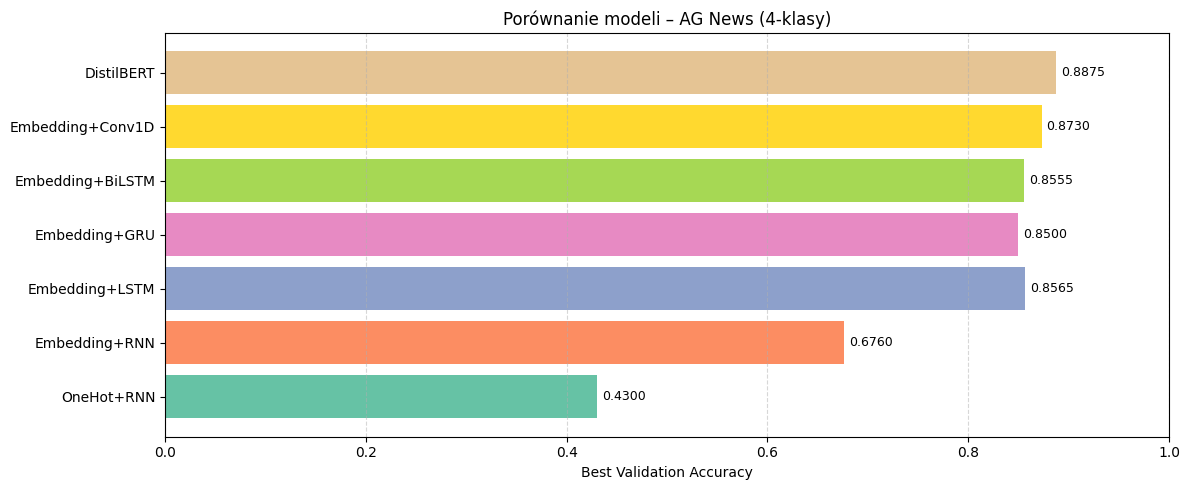

In [31]:
# ── Wykres porównawczy – tylko modele tekstowe ────────────────────────────────
acc_vals, acc_names = [], []
for name in text_models + ["LSTM (Optuna best)"]:
    if name in histories:
        acc_names.append(name)
        acc_vals.append(max(histories[name]["val_accuracy"]))

acc_names.append("DistilBERT")
acc_vals.append(max(bert_val_accs))

colors = sns.color_palette("Set2", len(acc_names))
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(acc_names, acc_vals, color=colors)
ax.set_xlim(0, 1)
ax.set_xlabel("Best Validation Accuracy")
ax.set_title("Porównanie modeli – AG News (4-klasy)")
for bar, val in zip(bars, acc_vals):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9)
ax.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout(); plt.show()


## Wnioski

### Modele tekstowe (AG News)
| Obserwacja | Wniosek |
|---|---|
| One-hot + SimpleRNN | Najsłabszy wariant – reprezentacja rozrzedzona, brak semantyki |
| Embedding + GRU / LSTM | Znacznie lepsze wyniki dzięki gęstym reprezentacjom wektorowym |
| BiLSTM | Dwukierunkowe przetwarzanie poprawia wyniki o ~1-2 pp |
| Conv1D | Szybki i skuteczny – wychwytuje lokalne n-gramy |
| DistilBERT | Najwyższa dokładność dzięki pre-treningowi na dużym korpusie (transfer learning) |
| Optuna LSTM | Automatyczne HPO pozwala zbliżyć się do wyników BiLSTM bez ręcznego tuningu |

### Funkcje aktywacji w GRU
- `tanh` (domyślna) – najlepsza dla warstw rekurencyjnych (gradient-friendly)
- `relu` – ryzyko eksplodującego gradientu w RNN
- `sigmoid` – zbyt silne tłumienie, wolna zbieżność

### Dane czasowe (Energia elektryczna)
- **GRU i Stacked LSTM** osiągają najniższy MAE
- **Conv1D+LSTM** oferuje dobry kompromis między szybkością a dokładnością
- Early Stopping skutecznie zapobiega przeuczeniu

### Kluczowe wnioski ogólne
1. **Word embeddings > one-hot** – gęsta reprezentacja semantyczna zawsze wygrywa przy ograniczonej pamięci
2. **Transfer learning (BERT/DistilBERT)** jest najskuteczniejszy przy małych zbiorach treningowych
3. **Optuna** automatyzuje HPO i może zastąpić ręczne eksperymenty z siatką parametrów
4. **Dropout + EarlyStopping** są kluczowe dla regularyzacji modeli sekwencyjnych
